<a href="https://colab.research.google.com/github/PradenaTiara/Machine-Learning/blob/main/SLR_672022028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SLR

In [ ]:
#import dimulaiiiii
import pandas as pd
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
#ambil data
!wget -O FuelConsumption.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv

--2024-06-06 15:48:36--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K  --.-KB/s    in 0.04s   

2024-06-06 15:48:36 (1.55 MB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



In [ ]:
#bikin dataframe
data = pd.read_csv('FuelConsumption.csv')
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
dataku = data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
dataku.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


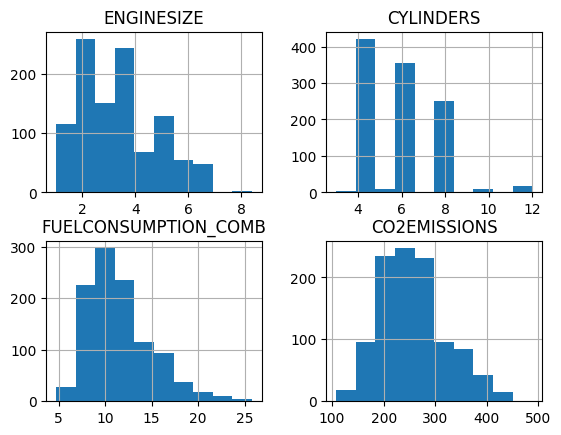

In [ ]:
#silakan bikin visualisasi utk lihat fitur/kolom
vis = dataku[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
vis.hist()
plt.show()

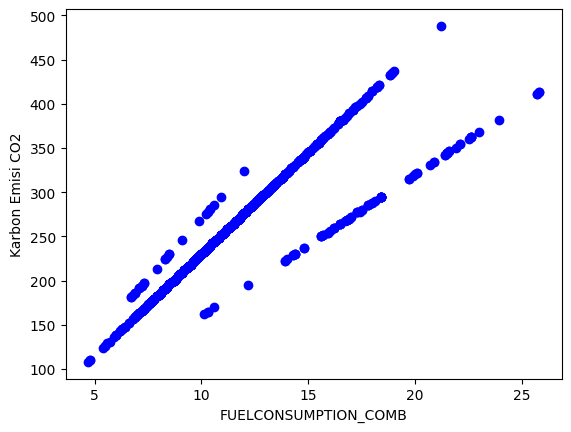

In [ ]:
#kita harus cek korelasi/hubungan dua variabel/fitur/kolom
plt.scatter(dataku.FUELCONSUMPTION_COMB, dataku.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Karbon Emisi CO2")
plt.show()

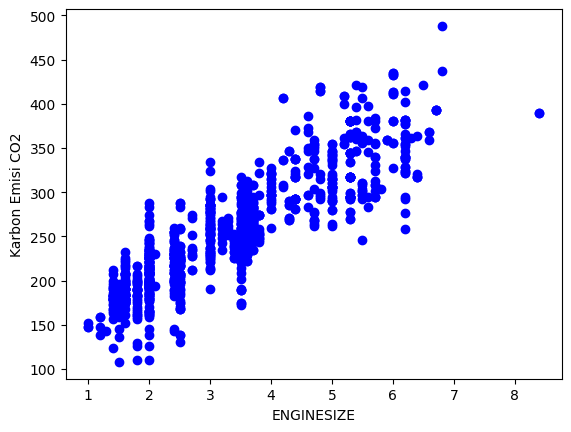

In [ ]:
plt.scatter(dataku.ENGINESIZE, dataku.CO2EMISSIONS, color='blue')
plt.xlabel("ENGINESIZE")
plt.ylabel("Karbon Emisi CO2")
plt.show()

TUGAS 1 Membandingkan Cylinder dengan Emisi CO2

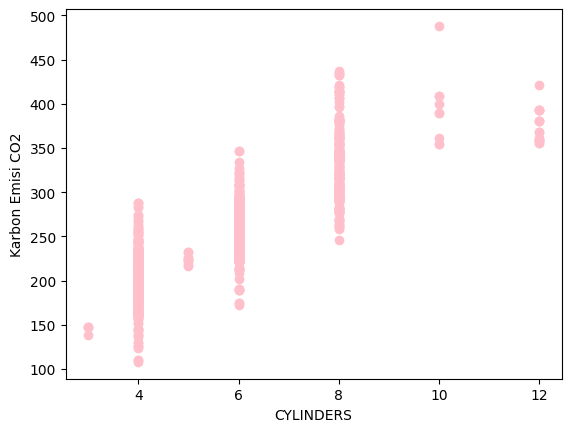

In [ ]:
#TUGASSSSSSSS

plt.scatter(dataku.CYLINDERS, dataku.CO2EMISSIONS, color='pink')
plt.xlabel("CYLINDERS")
plt.ylabel("Karbon Emisi CO2")
plt.show()

#Coba bandingkan Cylinder dengan Emisi CO2


TUGAS 2 Garis Persamaan untuk sigmoid dengan dataset china_gdp

In [ ]:
#lihat China punya pendapatan per kapita!
!wget -nv -O china_gdp.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/china_gdp.csv

2024-06-06 15:49:49 URL:https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/china_gdp.csv [1218/1218] -> "china_gdp.csv" [1]


In [ ]:
df = pd.read_csv('china_gdp.csv')
df.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


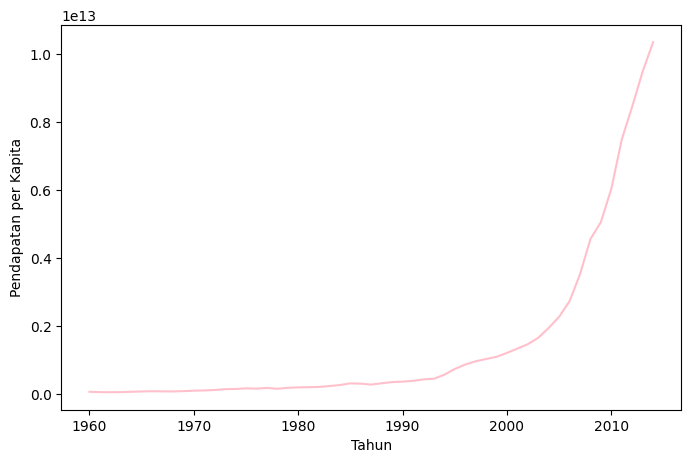

In [ ]:
#tampilin ke grafik pakai plot
plt.figure(figsize=(8,5))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, color='pink')
plt.ylabel('Pendapatan per Kapita')
plt.xlabel('Tahun')
plt.show()

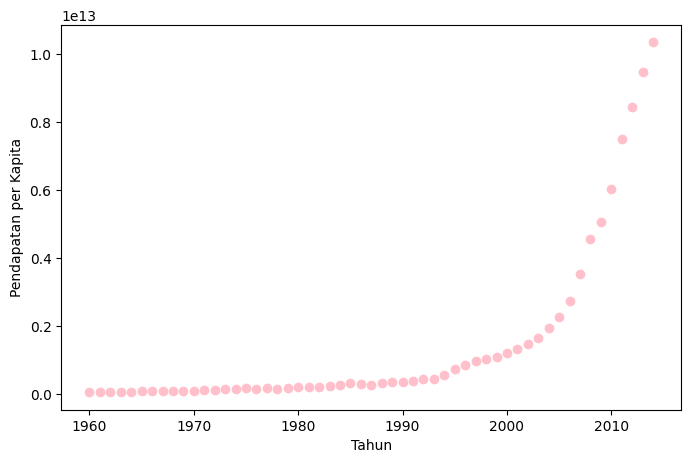

In [ ]:
#tampilin ke grafik pakai scatter
plt.figure(figsize=(8,5))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.scatter(x_data, y_data, color='pink')
plt.ylabel('Pendapatan per Kapita')
plt.xlabel('Tahun')
plt.show()

In [ ]:
from scipy.optimize import curve_fit

<ipython-input-56-abdec950782b>:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_data, y_data, 'ro',color='pink', label='Data Real')


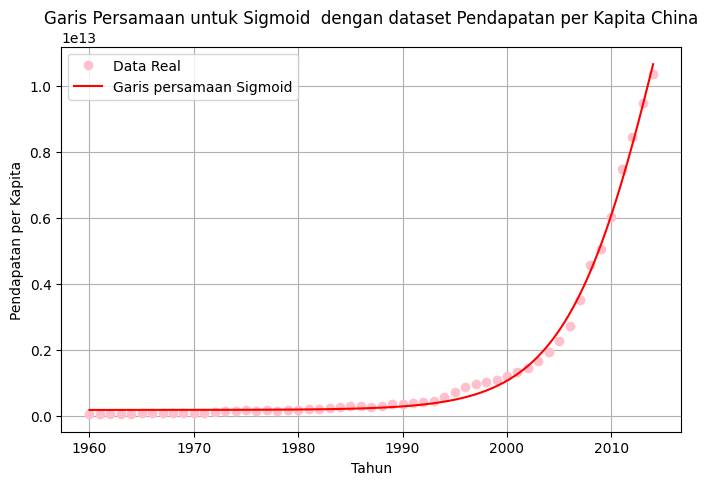

In [ ]:
#TUGASSSSSSSS

def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

x_data = df["Year"].values
y_data = df["Value"].values

popt, pcov = curve_fit(sigmoid, x_data, y_data, p0=[max(y_data), np.median(x_data), 1, min(y_data)])

x_sigmoid = np.linspace(min(x_data), max(x_data), 300)
y_sigmoid = sigmoid(x_sigmoid, *popt)

plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'ro',color='pink', label='Data Real')
plt.plot(x_sigmoid, y_sigmoid, color='red', label='Garis persamaan Sigmoid')
plt.ylabel('Pendapatan per Kapita')
plt.xlabel('Tahun')
plt.title('Garis Persamaan untuk Sigmoid  dengan dataset Pendapatan per Kapita China')
plt.legend()
plt.grid(True)
plt.show()

#Coba bikin garis persamaan untuk sigmoid dengan dataset china_gdp ini

TUGAS 3 PERHITUNGAN AKURASI DARI MODEL

In [ ]:
#TUGASSSSSSSS
from sklearn.metrics import r2_score

y_pred = sigmoid(x_data, *popt)
mse = mean_squared_error(y_data, y_pred)
r2 = r2_score(y_data, y_pred)

print(f"Parameter yang sesuai: L = {popt[0]}, x0 = {popt[1]}, k = {popt[2]}")
print(f'Mean Squared Error : {mse}')
print(f'R-squared : {r2}')

#Coba bikin perhitungan akurasi dari modelnya

Parameter yang sesuai: L = 24519882251385.92, x0 = 2015.3663220001893, k = 0.21369867233976395
Mean Squared Error : 2.377420379440932e+22
R-squared : 0.9961259476184756
